# Event-locked CTDS latent dynamics on Runyan PPC data

Fit a Cell-Type Dynamical System (CTDS) to one Potter / Bassi / Runyan 2024
session (`FU1-00 / 2022-03-17`) using the inhibitory population activity events
from `D_onsets_v2.mat` as trials. Each event provides a 501-frame window aligned
to either a SOM-led or PV-led inhibitory burst. After fitting we look at how
the inferred E and I latents evolve around event onsets and compare SOM vs PV
conditions.

Cell-type convention (per the paper): `cellid == 0` (GCaMP-only) → putative
pyramidal / E; `cellid == 1` (mCherry) → SOM; `cellid == 2` (tdTomato) → PV.
We pool SOM and PV into a single inhibitory group for this fit.

In [16]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.stats import mannwhitneyu

import jax
import jax.numpy as jnp

from pillow_lab_rotation.jax_ctds import CTDSJax

In [17]:
DATA_ROOT = Path('../data/runyan_data')
MOUSE = 'FU1-00'
DATE = '2022-03-17'
SESSION_DIR = DATA_ROOT / MOUSE / DATE

In [18]:
activity   = loadmat(SESSION_DIR / 'activity.mat',
                     squeeze_me=True, struct_as_record=False)['combined_info']
clustering = loadmat(SESSION_DIR / 'clustering.mat',
                     squeeze_me=True, struct_as_record=False)['clustering_info']
D_onsets   = loadmat(SESSION_DIR / 'D_onsets_v2.mat',
                     squeeze_me=True, struct_as_record=False)['D_onsets']

In [19]:
# Curated activity & cell-type labels.
dff      = activity.dff                  # (365, 54800) dF/F
cellids  = clustering.cellids            # (365,)  0=putative E, 1=SOM, 2=PV
fs       = float(activity.Fall.ops.fs)   # 30 Hz
fpts     = np.atleast_1d(activity.metaData.frames_per_Tseries)

n_e  = int((cellids == 0).sum())
n_s  = int((cellids == 1).sum())
n_pv = int((cellids == 2).sum())
print(f'session: {activity.tag}  ({dff.shape[0]} cells, T={dff.shape[1]} '
      f'@ {fs:.0f} Hz ≈ {dff.shape[1]/fs/60:.1f} min, {len(fpts)} TSeries)')
print(f'cell types — E (unlabeled): {n_e}, SOM: {n_s}, PV: {n_pv}')
n_som_evt = sum(ev.condition == 'SOM' for ev in D_onsets)
n_pv_evt  = sum(ev.condition == 'PV'  for ev in D_onsets)
print(f'D_onsets — n_events = {len(D_onsets)} '
      f'(SOM-led: {n_som_evt}, PV-led: {n_pv_evt})')

session: FU1-00__2022-03-17  (365 cells, T=54800 @ 30 Hz ≈ 30.4 min, 32 TSeries)
cell types — E (unlabeled): 286, SOM: 14, PV: 65
D_onsets — n_events = 97 (SOM-led: 50, PV-led: 47)


In [20]:
fpts

array([2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300,
       2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300,
       2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300],
      dtype=uint16)

## Preprocessing

1. Reorder neurons into `[E rows, I rows]` to match `CTDSJax`'s convention.
2. Z-score each cell over the full trace. CTDS has no emission bias and dF/F
   variance differs 10–100× across cells; without z-scoring `R` is dominated
   by the loudest neurons.
3. Set a downsampling factor for binning. At 30 Hz consecutive dF/F frames have
   r > 0.95 autocorrelation from GCaMP6f kinetics, which drives `A` toward
   identity. We bin to ~5 Hz so one timestep is comparable to the indicator
   decay.

In [21]:
e_idx = np.where(cellids == 0)[0]                        # putative pyramidal
i_idx = np.where((cellids == 1) | (cellids == 2))[0]     # SOM + PV pooled
ei_order = np.concatenate([e_idx, i_idx])
Ne, Ni = len(e_idx), len(i_idx)
N = Ne + Ni

# z-score per cell across the full session
Y_raw = dff[ei_order]
Y_z = (Y_raw - Y_raw.mean(1, keepdims=True)) / Y_raw.std(1, keepdims=True)

ds_factor = 6                                            # 30 Hz / 6 = 5 Hz
fs_eff = fs / ds_factor

print(f'Ne={Ne} (E), Ni={Ni} (SOM + PV pooled), N={N}')
print(f'Y_z shape: {Y_z.shape}, effective fs after binning: {fs_eff:.1f} Hz')

Ne=286 (E), Ni=79 (SOM + PV pooled), N=365
Y_z shape: (365, 54800), effective fs after binning: 5.0 Hz


## Build event-aligned trial tensor

`D_onsets` only stores E cells, so we extract each `(N, 501)` window from the
z-scored full trace `Y_z` to get both E and I in `[E, I]` order. After
truncating each window to a multiple of `ds_factor` and binning, each event
becomes a single trial of shape `(T_evt, N, 1)`.

Verified alignment: column `k` of an event window maps to frame
`onset + k - PRE` in the 54800-frame full trace, with `PRE = 101`. So each
window covers 101 frames (~3.4 s) before onset and 399 frames (~13.3 s) after.

In [22]:
PRE = 101
WIN = D_onsets[0].dff.shape[1]                           # 501

onsets = np.array([ev.onset for ev in D_onsets])
condition = np.array([ev.condition for ev in D_onsets])
assert (onsets >= PRE).all() and (onsets + (WIN - PRE) <= Y_z.shape[1]).all()

# (1) extract per-event windows from the z-scored, [E,I]-ordered trace
windows = np.stack([Y_z[:, o - PRE : o - PRE + WIN] for o in onsets])

# (2) bin within each window (drops 501 - 498 = 3 trailing frames)
WIN_TRUNC = (WIN // ds_factor) * ds_factor               # 498
T_evt = WIN_TRUNC // ds_factor                           # 83
windows_ds = (windows[:, :, :WIN_TRUNC]
                     .reshape(len(onsets), N, T_evt, ds_factor)
                     .mean(-1))

# (3) reshape to CTDS observation convention (n_trials, T, N, 1)
obs_evt = windows_ds.transpose(0, 2, 1)[..., None].astype(np.float32)

# Time axis in seconds relative to onset
onset_bin = PRE / ds_factor                              # ~16.83 (col index)
t_evt = (np.arange(T_evt) - onset_bin) / fs_eff

is_som = condition == 'SOM'
is_pv  = condition == 'PV'

print(f'obs_evt: {obs_evt.shape}  (n_trials, T, N, 1)')
print(f'T_evt={T_evt} bins @ {fs_eff:.1f} Hz spans '
      f'[{t_evt[0]:.2f}, {t_evt[-1]:.2f}] s rel. onset')
print(f'event counts — SOM: {is_som.sum()}, PV: {is_pv.sum()}')

obs_evt: (97, 83, 365, 1)  (n_trials, T, N, 1)
T_evt=83 bins @ 5.0 Hz spans [-3.37, 13.03] s rel. onset
event counts — SOM: 50, PV: 47


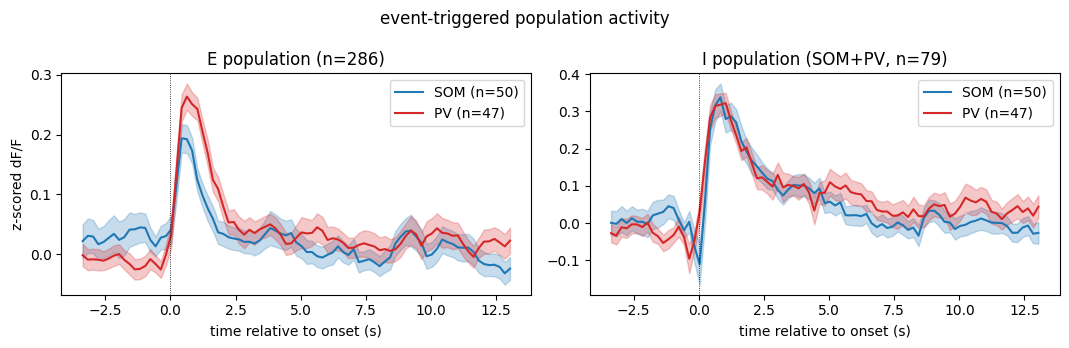

In [23]:
# Sanity check: event-triggered average of E- and I-population mean activity, SOM vs PV.
def evt_mean(arr, mask, cell_slice):
    pop = arr[mask, :, cell_slice, 0].mean(axis=2)        # (n_evt_in_group, T)
    return pop.mean(0), pop.std(0) / np.sqrt(pop.shape[0])

mu_E_s, sem_E_s = evt_mean(obs_evt, is_som, slice(0,  Ne))
mu_E_p, sem_E_p = evt_mean(obs_evt, is_pv,  slice(0,  Ne))
mu_I_s, sem_I_s = evt_mean(obs_evt, is_som, slice(Ne, N))
mu_I_p, sem_I_p = evt_mean(obs_evt, is_pv,  slice(Ne, N))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharex=True)

axes[0].plot(t_evt, mu_E_s, color='C0', label=f'SOM (n={is_som.sum()})')
axes[0].fill_between(t_evt, mu_E_s - sem_E_s, mu_E_s + sem_E_s, color='C0', alpha=0.25)
axes[0].plot(t_evt, mu_E_p, color='C3', label=f'PV (n={is_pv.sum()})')
axes[0].fill_between(t_evt, mu_E_p - sem_E_p, mu_E_p + sem_E_p, color='C3', alpha=0.25)
axes[0].axvline(0, color='k', lw=0.6, ls=':')
axes[0].set_xlabel('time relative to onset (s)')
axes[0].set_ylabel('z-scored dF/F')
axes[0].set_title(f'E population (n={Ne})')
axes[0].legend()

axes[1].plot(t_evt, mu_I_s, color='C0', label=f'SOM (n={is_som.sum()})')
axes[1].fill_between(t_evt, mu_I_s - sem_I_s, mu_I_s + sem_I_s, color='C0', alpha=0.25)
axes[1].plot(t_evt, mu_I_p, color='C3', label=f'PV (n={is_pv.sum()})')
axes[1].fill_between(t_evt, mu_I_p - sem_I_p, mu_I_p + sem_I_p, color='C3', alpha=0.25)
axes[1].axvline(0, color='k', lw=0.6, ls=':')
axes[1].set_xlabel('time relative to onset (s)')
axes[1].set_title(f'I population (SOM+PV, n={Ni})')
axes[1].legend()

fig.suptitle('event-triggered population activity')
fig.tight_layout()

## Fit CTDS

`CTDSJax(De, Di, Ne, Ni)` enforces:

- Dale's law on `A`: E columns ≥ 0, I columns ≤ 0 (off-diagonals).
- Block-diagonal non-negative `C`: E neurons load only E latents, I neurons
  load only I latents.
- Diagonal `R`.

We use a small latent budget — `De=10` E latents and `Di=5` I latents. Random
init is enough at this scale; switch to `init_params(obs_evt_jax)` for
EIRNN/NMF init if EM gets stuck.

In [68]:
De, Di = 5, 10

obs_evt_jax = jnp.asarray(obs_evt)
model = CTDSJax(De=De, Di=Di, Ne=Ne, Ni=Ni, key=jax.random.PRNGKey(0))
model.init_params()
model.fit(obs_evt_jax, verbose=True, max_iter=30)

Iteration 0: LL = -456.144135
Iteration 1: LL = -371.600433
Iteration 2: LL = -353.329681
Iteration 3: LL = -347.745941
Iteration 4: LL = -345.767822
Iteration 5: LL = -344.851440
Iteration 6: LL = -344.301422
Iteration 7: LL = -343.892517
Iteration 8: LL = -343.569550
Iteration 9: LL = -343.329590
Iteration 10: LL = -343.162140
Iteration 11: LL = -343.044434
Iteration 12: LL = -342.955200
Iteration 13: LL = -342.879822
Iteration 14: LL = -342.810455
Iteration 15: LL = -342.745361
Iteration 16: LL = -342.686829
Iteration 17: LL = -342.637665
Iteration 18: LL = -342.597839
Iteration 19: LL = -342.565765
Iteration 20: LL = -342.539795
Iteration 21: LL = -342.518646
Iteration 22: LL = -342.501099
Iteration 23: LL = -342.486542
Iteration 24: LL = -342.473999
Iteration 25: LL = -342.463470
Iteration 26: LL = -342.454407
Iteration 27: LL = -342.446381
Iteration 28: LL = -342.439270
Iteration 29: LL = -342.433197
Iteration 30: LL = -342.427734


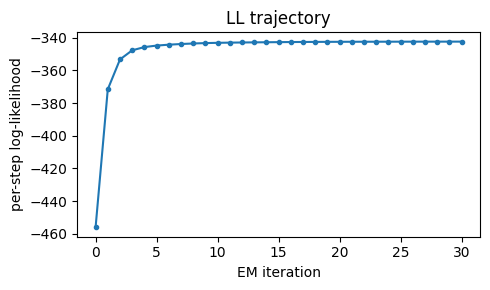

In [69]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(model.ll_history, marker='o', ms=3)
ax.set_xlabel('EM iteration')
ax.set_ylabel('per-step log-likelihood')
ax.set_title('LL trajectory')
fig.tight_layout()

## Inspect fit

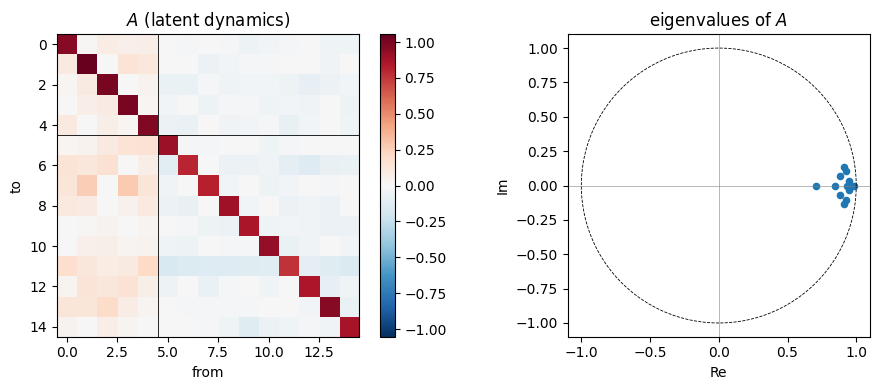

In [70]:
A = np.asarray(model.A)
C = np.asarray(model.C)
R = np.asarray(model.R)
Q = np.asarray(model.Q)
m_evt = np.asarray(model.m).squeeze(-1)                  # (n_evt, T_evt, D_lat)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vmax = np.abs(A).max()
imA = axes[0].imshow(A, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='equal')
axes[0].axhline(De - 0.5, color='k', lw=0.6)
axes[0].axvline(De - 0.5, color='k', lw=0.6)
axes[0].set_title(r'$A$ (latent dynamics)')
axes[0].set_xlabel('from'); axes[0].set_ylabel('to')
fig.colorbar(imA, ax=axes[0], fraction=0.046)

eigvals = np.linalg.eigvals(A)
theta = np.linspace(0, 2 * np.pi, 200)
axes[1].plot(np.cos(theta), np.sin(theta), 'k--', lw=0.6)
axes[1].scatter(eigvals.real, eigvals.imag, s=20)
axes[1].axhline(0, color='gray', lw=0.4); axes[1].axvline(0, color='gray', lw=0.4)
axes[1].set_aspect('equal')
axes[1].set_xlabel('Re'); axes[1].set_ylabel('Im')
axes[1].set_title('eigenvalues of $A$')
fig.tight_layout()

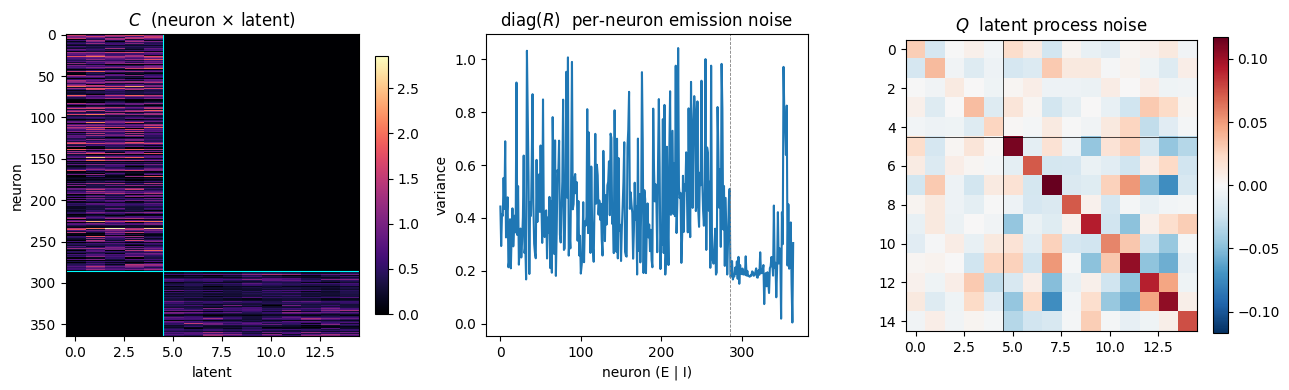

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

imC = axes[0].imshow(C, cmap='magma', aspect='auto', interpolation='none')
axes[0].axhline(Ne - 0.5, color='cyan', lw=0.8)
axes[0].axvline(De - 0.5, color='cyan', lw=0.8)
axes[0].set_title(r'$C$  (neuron $\times$ latent)')
axes[0].set_xlabel('latent'); axes[0].set_ylabel('neuron')
fig.colorbar(imC, ax=axes[0], fraction=0.04)

axes[1].plot(np.diag(R))
axes[1].axvline(Ne - 0.5, color='gray', ls='--', lw=0.6)
axes[1].set_title(r'$\mathrm{diag}(R)$  per-neuron emission noise')
axes[1].set_xlabel('neuron (E | I)')
axes[1].set_ylabel('variance')

vmaxQ = np.abs(Q).max()
imQ = axes[2].imshow(Q, cmap='RdBu_r', vmin=-vmaxQ, vmax=vmaxQ)
axes[2].axhline(De - 0.5, color='k', lw=0.5); axes[2].axvline(De - 0.5, color='k', lw=0.5)
axes[2].set_title(r'$Q$  latent process noise')
fig.colorbar(imQ, ax=axes[2], fraction=0.046)

fig.tight_layout()

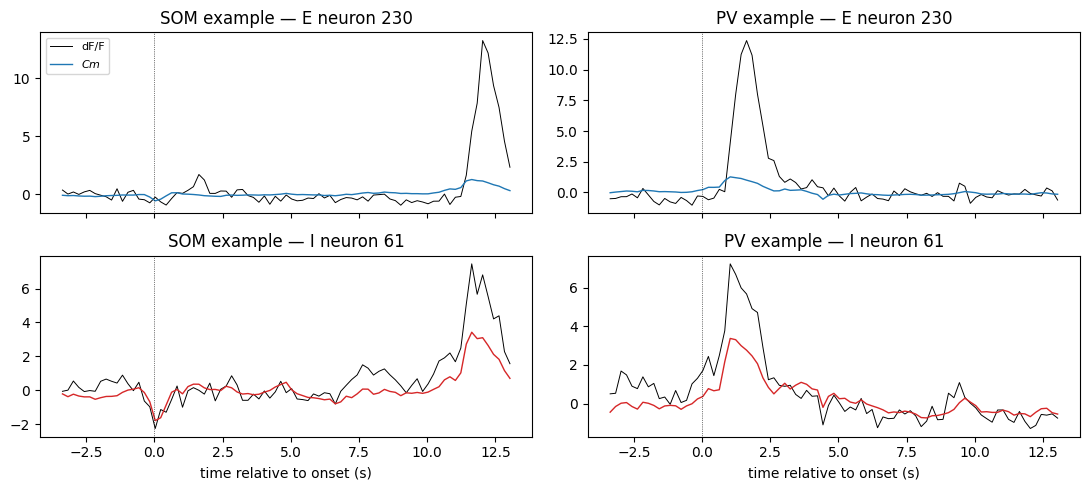

In [72]:
# Single-event reconstruction y_hat = C m for one example SOM event and one PV event.
ex_som = int(np.where(is_som)[0][0])
ex_pv  = int(np.where(is_pv)[0][0])

fig, axes = plt.subplots(2, 2, figsize=(11, 5), sharex=True)
for col, (label, ev_i) in enumerate([('SOM example', ex_som), ('PV example', ex_pv)]):
    y_obs = obs_evt[ev_i, :, :, 0]
    y_hat = m_evt[ev_i] @ C.T

    e_pick = int(np.argmax(np.abs(y_obs[:, :Ne]).max(0)))
    i_pick = Ne + int(np.argmax(np.abs(y_obs[:, Ne:]).max(0)))

    axes[0, col].plot(t_evt, y_obs[:, e_pick], color='k', lw=0.7, label='dF/F')
    axes[0, col].plot(t_evt, y_hat[:, e_pick], color='C0', lw=1.0, label=r'$Cm$')
    axes[0, col].axvline(0, color='k', ls=':', lw=0.5)
    axes[0, col].set_title(f'{label} — E neuron {e_pick}')

    axes[1, col].plot(t_evt, y_obs[:, i_pick], color='k', lw=0.7)
    axes[1, col].plot(t_evt, y_hat[:, i_pick], color='C3', lw=1.0)
    axes[1, col].axvline(0, color='k', ls=':', lw=0.5)
    axes[1, col].set_title(f'{label} — I neuron {i_pick - Ne}')
    axes[1, col].set_xlabel('time relative to onset (s)')

axes[0, 0].legend(fontsize=8)
fig.tight_layout()

## Event-locked latent dynamics

The headline question: do the inferred E and I latents differentiate SOM-led
vs PV-led inhibitory bursts? For each latent we compute the average trajectory
across SOM events and across PV events.

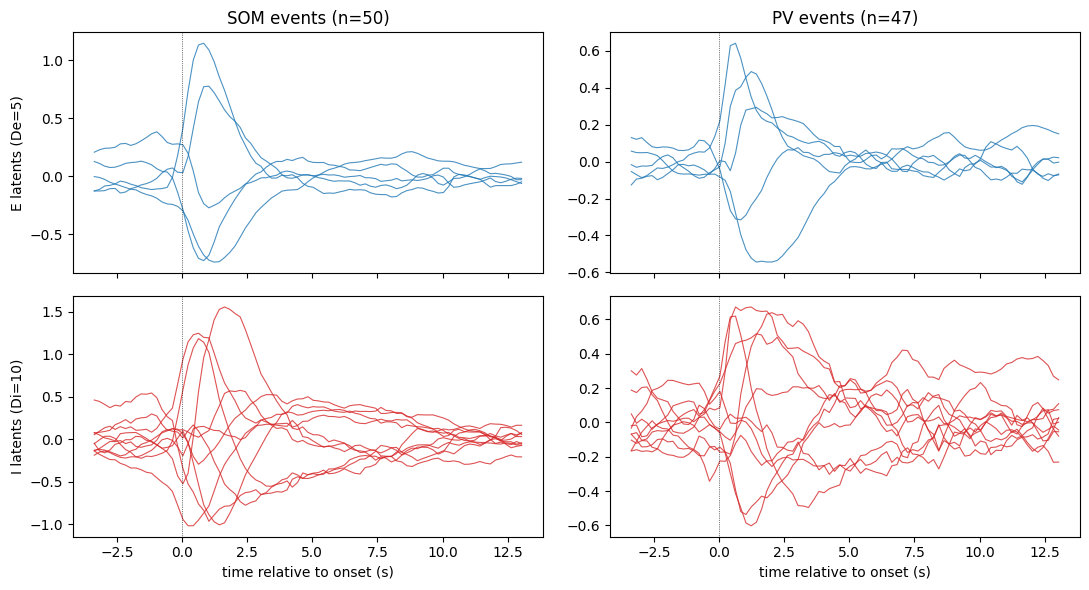

In [73]:
def latent_avg(m_arr, mask):
    sel = m_arr[mask]                                    # (n_evt, T, D)
    return sel.mean(0), sel.std(0) / np.sqrt(sel.shape[0])

mu_som, sem_som = latent_avg(m_evt, is_som)
mu_pv,  sem_pv  = latent_avg(m_evt, is_pv)

# All E and I latents overlaid, one panel per (population, condition)
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
for d in range(De):
    axes[0, 0].plot(t_evt, mu_som[:, d], color='C0', lw=0.8, alpha=0.8)
    axes[0, 1].plot(t_evt, mu_pv[:, d],  color='C0', lw=0.8, alpha=0.8)
for d in range(Di):
    axes[1, 0].plot(t_evt, mu_som[:, De + d], color='C3', lw=0.8, alpha=0.8)
    axes[1, 1].plot(t_evt, mu_pv[:, De + d],  color='C3', lw=0.8, alpha=0.8)

axes[0, 0].set_title(f'SOM events (n={is_som.sum()})')
axes[0, 1].set_title(f'PV events (n={is_pv.sum()})')
axes[0, 0].set_ylabel(f'E latents (De={De})')
axes[1, 0].set_ylabel(f'I latents (Di={Di})')
for ax in axes.flat:
    ax.axvline(0, color='k', ls=':', lw=0.5)
for ax in axes[-1]:
    ax.set_xlabel('time relative to onset (s)')
fig.tight_layout()

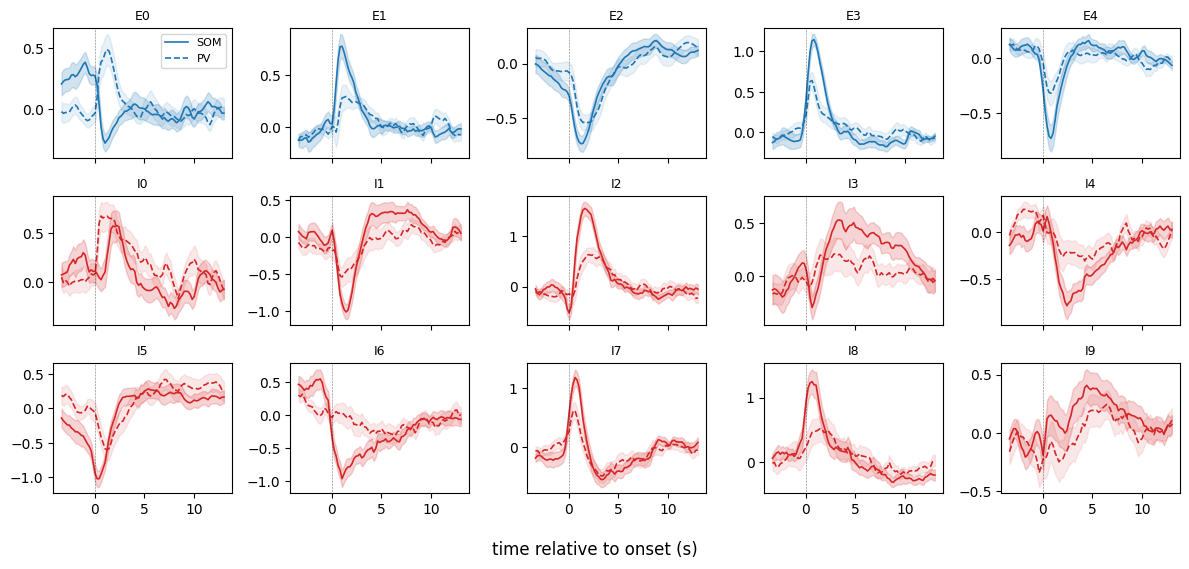

In [74]:
# Per-latent SOM vs PV overlay — does each latent dimension distinguish
# the two event types? Solid = SOM, dashed = PV; shaded = SEM across events.
n_cols = 5
n_rows = int(np.ceil((De + Di) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.4 * n_cols, 1.9 * n_rows),
                         sharex=True)
axes = axes.flatten()
for d in range(De + Di):
    is_E = d < De
    color = 'C0' if is_E else 'C3'
    label = f'{"E" if is_E else "I"}{d if is_E else d - De}'
    axes[d].plot(t_evt, mu_som[:, d], color=color, lw=1.2, label='SOM')
    axes[d].plot(t_evt, mu_pv[:, d],  color=color, lw=1.2, ls='--', label='PV')
    axes[d].fill_between(t_evt,
                         mu_som[:, d] - sem_som[:, d], mu_som[:, d] + sem_som[:, d],
                         color=color, alpha=0.2)
    axes[d].fill_between(t_evt,
                         mu_pv[:, d] - sem_pv[:, d], mu_pv[:, d] + sem_pv[:, d],
                         color=color, alpha=0.1)
    axes[d].axvline(0, color='k', ls=':', lw=0.4)
    axes[d].set_title(label, fontsize=9)
for d in range(De + Di, len(axes)):
    axes[d].set_visible(False)
axes[0].legend(fontsize=8)
fig.supxlabel('time relative to onset (s)')
fig.tight_layout()

## E vs I reconstruction quality

Per-neuron variance explained by the smoothed reconstruction `y_hat = C m`
across all event trials.

E (n=286): mean R² = 0.205, median = 0.105
I (n=79): mean R² = 0.406, median = 0.368
Mann-Whitney U=5663, p=1.15e-11


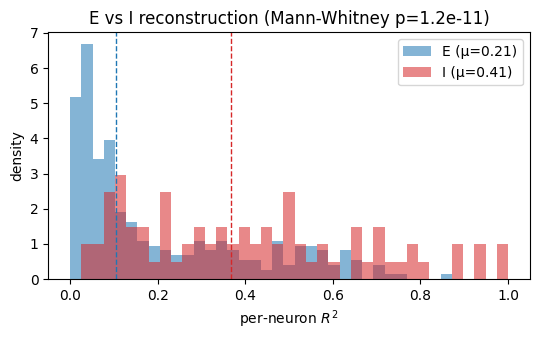

In [75]:
y_obs_all = obs_evt.squeeze(-1).reshape(-1, N)
y_hat_all = (m_evt @ C.T).reshape(-1, N)
resid = y_obs_all - y_hat_all
r2 = 1.0 - resid.var(0) / y_obs_all.var(0)               # (N,)

r2_E = r2[:Ne]
r2_I = r2[Ne:]
u, p = mannwhitneyu(r2_E, r2_I, alternative='two-sided')

print(f'E (n={Ne}): mean R² = {r2_E.mean():.3f}, median = {np.median(r2_E):.3f}')
print(f'I (n={Ni}): mean R² = {r2_I.mean():.3f}, median = {np.median(r2_I):.3f}')
print(f'Mann-Whitney U={u:.0f}, p={p:.2e}')

fig, ax = plt.subplots(figsize=(5.5, 3.5))
bins = np.linspace(min(0, r2.min()), 1.0, 40)
ax.hist(r2_E, bins=bins, alpha=0.55, color='C0', density=True,
        label=f'E (μ={r2_E.mean():.2f})')
ax.hist(r2_I, bins=bins, alpha=0.55, color='C3', density=True,
        label=f'I (μ={r2_I.mean():.2f})')
ax.axvline(np.median(r2_E), color='C0', ls='--', lw=1)
ax.axvline(np.median(r2_I), color='C3', ls='--', lw=1)
ax.set_xlabel(r'per-neuron $R^2$')
ax.set_ylabel('density')
ax.set_title(f'E vs I reconstruction (Mann-Whitney p={p:.1e})')
ax.legend()
fig.tight_layout()